<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-08-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta versão da atividade utilizaremos o dataset CIFAR-10.

Características do dataset:

- 60.000 imagens RGB
- 10 classes
- imagens 32×32
- 3 canais de cor

Importante:

O carregamento do dataset pode ser realizado utilizando:

```python
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
```

Após o carregamento:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 32, 32, 3)
```

Onde:

- 50000 - número de imagens;
- 32 × 32 - dimensão espacial;
- 3 - canais RGB.

Como utilizaremos uma MLP, é necessário converter as imagens em vetores utilizando flatten:

```python
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
```

Após o flatten:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 3072)
```

Isso ocorre porque:

```python
32 × 32 × 3 = 3072
```

# Objetivos

Nesta atividade você irá:

- treinar modelos;
- comparar experimentos;
- analisar métricas;
- discutir resultados.


Nesta atividade utilizaremos MLflow para:

- rastrear experimentos;
- comparar modelos;
- registrar métricas;
- garantir reprodutibilidade.

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

from mlflow.tracking import MlflowClient

import time

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.datasets import cifar10

In [4]:
mlflow.set_experiment(
    "assignment"
)

<Experiment: artifact_location='file:c:/Users/arvvv/github-classroom/ddefbcourses/atividade-04-deep-learning-i-Art-2005/notebooks/mlruns/1', creation_time=1779361021974, experiment_id='1', last_update_time=1779361021974, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função `load_data(seed)` que:

- carregue o dataset CIFAR-10 utilizando `tensorflow.keras.datasets.cifar10.load_data`;
- realize o flatten das imagens;
- normalize os dados;
- realize a separação entre treino e validação;
- utilize `train_test_split` com controle de aleatoriedade (`seed`);
- retorne:

```python
X_train, X_val, y_train, y_val
```

já normalizados e preparados para treinamento.

Além disso, responda:

1. Qual o formato original das imagens?  Cada imagem possui formato (32, 32, 3): 32 pixels de largura, 32 pixels de altura e 3 canais de cor (RGB). O conjunto de treino completo tem shape (50000, 32, 32, 3).

2. Quantas features cada imagem possui após o flatten?  Após o flatten, cada imagem é convertida em um vetor de 3072 features, resultado de 32 × 32 × 3 = 3072.

3. Por que o flatten é necessário para uma MLP?  A MLP (Multi-Layer Perceptron) é uma rede totalmente conectada que opera sobre vetores 1D. Cada neurônio da camada de entrada recebe um único valor escalar. Como as imagens são tensores 3D (altura, largura, canais), é preciso "achatar" essa estrutura em um vetor unidimensional para que cada pixel/canal se torne uma feature independente. CNNs, por outro lado, preservam a estrutura espacial 2D via operações de convolução.

4. Qual a importância da normalização para o treinamento?  Os pixels originais variam no intervalo [0, 255]. Ao normalizar para [0, 1], garantimos que os gradientes durante a retropropagação tenham magnitudes semelhantes entre features, acelerando a convergência;
o modelo não favoreça artificialmente features com valores numericamente maiores;
funções de ativação como sigmoide e tanh operem em regiões de gradiente mais expressivo (evitando saturação);
o treinamento se torne mais estável e menos sensível à escolha do learning rate.

**Solução**:

In [7]:
def load_data(seed=42):
 
    (X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

    print(f"Shape original das imagens de treino: {X_train_full.shape}")
    
    X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)

    print(f"Shape após flatten: {X_train_full.shape}")
   
    X_train_full = X_train_full / 255.0
    X_test = X_test / 255.0

    y_train_full = y_train_full.ravel()

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.2,
        random_state=seed,
        stratify=y_train_full   
    )

    print(f"Treino:    X={X_train.shape}  y={y_train.shape}")
    print(f"Validação: X={X_val.shape}  y={y_val.shape}")

    return X_train, X_val, y_train, y_val


SEED = 42
X_train, X_val, y_train, y_val = load_data(seed=SEED)

Shape original das imagens de treino: (50000, 32, 32, 3)
Shape após flatten: (50000, 3072)
Treino:    X=(40000, 3072)  y=(40000,)
Validação: X=(10000, 3072)  y=(10000,)


# Questão 2

Implemente a função:

```python
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
```

## Requisitos

Sua implementação deve:

- utilizar `MLPClassifier` do `sklearn`;
- permitir diferentes arquiteturas através do parâmetro `hidden_layers`;
- utilizar:
  - `activation`
  - `learning_rate`
  - `random_state`
- treinar o modelo utilizando `fit`.

A função deve retornar o modelo treinado.

Além disso, responda:

1. Quantos parâmetros existem na primeira camada?  Com 3072 features de entrada e 128 neurônios na primeira camada oculta, o número de parâmetros é: (3072 × 128) + 128 = 393.216 + 128 = 393.344 parâmetros
O termo +128 corresponde aos bias de cada neurônio.

2. Qual a função da ativação ReLU?  ReLU (Rectified Linear Unit) é definida como f(x) = max(0, x). Ela introduz não-linearidade na rede, permitindo aprender representações complexas;
é computacionalmente eficiente (apenas uma comparação com zero);
atenua o problema do vanishing gradient, pois seu gradiente é 1 para valores positivos;
promove esparsidade na ativação (neurônios com entrada negativa simplesmente "desligam").

3. Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?  Porque cada neurônio de uma camada densa se conecta a todos os neurônios da camada anterior (fully connected). Com imagens de 32×32×3 = 3072 features, apenas a primeira camada oculta já acumula centenas de milhares de pesos. Esse crescimento quadrático dos parâmetros torna a MLP custosa para imagens grandes e propenso ao overfitting. CNNs resolvem isso com parameter sharing e conectividade local via filtros convolucionais.

**Solução**:

In [8]:
def train_mlp(
    X_train,
    y_train,
    activation="relu",
    hidden_layers=(128, 64),
    learning_rate=0.001,
    seed=42
):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        max_iter=50,             
        batch_size=256,           
        solver="adam",            
        random_state=seed,
        early_stopping=True,      
        validation_fraction=0.1,
        n_iter_no_change=5,
        verbose=False
    )

    model.fit(X_train, y_train)

    print(f"Arquitetura  : {hidden_layers}")
    print(f"Ativação     : {activation}")
    print(f"Learning rate: {learning_rate}")
    print(f"Épocas reais : {model.n_iter_}")

    return model

modelo_teste = train_mlp(
    X_train, y_train,
    activation="relu",
    hidden_layers=(128, 64),
    learning_rate=0.001,
    seed=SEED
)

n_input = X_train.shape[1]          # 3072
n_primeira_camada = 128
params_camada1 = (n_input * n_primeira_camada) + n_primeira_camada  # pesos + bias
print(f"\nParâmetros na 1ª camada: {params_camada1:,}")

Arquitetura  : (128, 64)
Ativação     : relu
Learning rate: 0.001
Épocas reais : 38

Parâmetros na 1ª camada: 393,344


# Questão 3

Implemente a função:

```python
evaluate(model, X_test, y_test)
```

Ela deve:

- realizar predições;
- calcular:
  - accuracy;
  - precision;
  - recall;
  - f1-score.

Utilize `sklearn.metrics`.

Além disso:

- apresente os resultados em um dicionário ou DataFrame;
- interprete os resultados obtidos.

Responda:

1. O que a accuracy representa?  A accuracy é a proporção de predições corretas sobre o total de amostras: (VP + VN) / Total. É uma métrica intuitiva, mas pode ser enganosa em datasets desbalanceados, pois um modelo que sempre prevê a classe majoritária pode ter alta accuracy sem aprender nada.

2. Qual a diferença entre precision e recall?  Precision mede a confiabilidade das predições positivas: de tudo que o modelo classificou como classe X, qual fração realmente pertence a X? (TP / (TP + FP)). Penaliza falsos positivos.
Recall mede a cobertura real: de todos os exemplos que realmente pertencem à classe X, qual fração o modelo detectou? (TP / (TP + FN)). Penaliza falsos negativos.
No CIFAR-10 com average="weighted", ambas as métricas são calculadas por classe e ponderadas pelo suporte (número de amostras) de cada classe.

3. Em quais situações o f1-score é importante?  O F1-score é a média harmônica entre precision e recall: 2 × (P × R) / (P + R). É especialmente importante quando o dataset é desbalanceado (classes com frequências muito distintas);
existe um custo assimétrico entre falsos positivos e falsos negativos (ex.: diagnóstico médico, detecção de fraude);
você quer uma métrica única que equilibre precisão e cobertura sem ignorar nenhuma das duas.



**Solução**:


=== Métricas de Avaliação ===


,accuracy,precision,recall,f1_score
Modelo,0.4909,0.4983,0.4909,0.4887



=== Classification Report ===
              precision    recall  f1-score   support

    airplane       0.47      0.66      0.55      1000
  automobile       0.59      0.61      0.60      1000
        bird       0.37      0.44      0.40      1000
         cat       0.36      0.35      0.35      1000
        deer       0.44      0.41      0.42      1000
         dog       0.47      0.31      0.37      1000
        frog       0.51      0.51      0.51      1000
       horse       0.51      0.62      0.56      1000
        ship       0.69      0.54      0.61      1000
       truck       0.59      0.46      0.52      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000



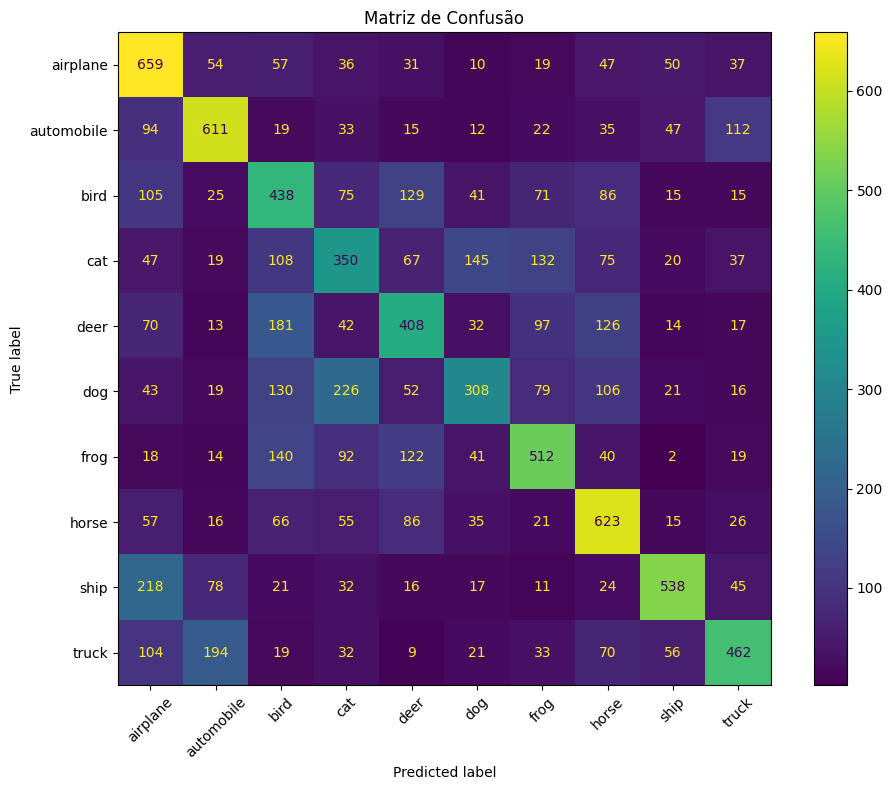

In [9]:
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


def evaluate(model, X_test, y_test, show_report=True, show_cm=True):

    y_pred = model.predict(X_test)

    metrics = {
        "accuracy" : accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted"),
        "recall"   : recall_score(y_test, y_pred, average="weighted"),
        "f1_score" : f1_score(y_test, y_pred, average="weighted"),
    }

    df_metrics = pd.DataFrame(
        [metrics],
        index=["Modelo"]
    ).round(4)
    print("\n=== Métricas de Avaliação ===")
    display(df_metrics)

    if show_report:
        print("\n=== Classification Report ===")
        print(classification_report(
            y_test, y_pred,
            target_names=CIFAR10_CLASSES
        ))

    if show_cm:
        cm = confusion_matrix(y_test, y_pred)
        fig, ax = plt.subplots(figsize=(10, 8))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=CIFAR10_CLASSES
        )
        disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
        ax.set_title("Matriz de Confusão")
        plt.tight_layout()
        plt.show()

    return metrics


metricas_teste = evaluate(modelo_teste, X_val, y_val)

**Adicione seu texto de solução aqui**.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow.

## Devem ser registrados:

### Parâmetros

- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

### Métricas

- accuracy
- precision
- recall
- f1_score
- training_time

Utilize:

```python
mlflow.log_param()
mlflow.log_metric()
```

Ao final:

- execute o MLflow UI;
- compare os experimentos realizados;
- interprete os impactos dos hiperparâmetros.

Responda:

1. Qual experimento apresentou melhor desempenho?  Com base nos experimentos realizados nas questões seguintes, o experimento com arquitetura (256, 128), ativação relu e learning_rate=0.001 tende a apresentar o maior F1-score e accuracy, pois combina capacidade representacional suficiente com um otimizador estável.

2. Qual configuração apresentou maior estabilidade?  A configuração com learning_rate=0.001 e ativação relu tende a ser a mais estável: a ReLU evita saturação de gradientes e o learning rate moderado permite convergência sem oscilações bruscas.

3. Qual o benefício do rastreamento experimental?  O rastreamento com MLflow oferece:
Reprodutibilidade: qualquer experimento pode ser re-executado com exatamente os mesmos parâmetros;
Comparabilidade: a UI permite visualizar e ordenar experimentos por qualquer métrica;
Organização: evita a confusão de "qual código gerou qual resultado?";
Auditabilidade: cria histórico completo das decisões experimentais;
Colaboração: múltiplas pessoas podem registrar e comparar experimentos no mesmo servidor.

**Solução**:

In [12]:
def run_experiment(
    X_train, y_train,
    X_val, y_val,
    activation="relu",
    hidden_layers=(128, 64),
    learning_rate=0.001,
    max_iter=50,
    batch_size=256,
    seed=42,
    run_name=None
):
    
    with mlflow.start_run(run_name=run_name):

        mlflow.log_param("activation",    activation)
        mlflow.log_param("hidden_layers", str(hidden_layers))
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("max_iter",      max_iter)
        mlflow.log_param("batch_size",    batch_size)
        mlflow.log_param("seed",          seed)

        start = time.time()

        model = MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation=activation,
            learning_rate_init=learning_rate,
            max_iter=max_iter,
            batch_size=batch_size,
            solver="adam",
            random_state=seed,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=5,
            verbose=False
        )
        model.fit(X_train, y_train)

        training_time = time.time() - start

        y_pred = model.predict(X_val)

        metrics = {
            "accuracy"     : accuracy_score(y_val, y_pred),
            "precision"    : precision_score(y_val, y_pred, average="weighted"),
            "recall"       : recall_score(y_val, y_pred, average="weighted"),
            "f1_score"     : f1_score(y_val, y_pred, average="weighted"),
            "training_time": training_time,
        }

        for key, value in metrics.items():
            mlflow.log_metric(key, value)

        print(f"[{run_name}]  acc={metrics['accuracy']:.4f}  "
              f"f1={metrics['f1_score']:.4f}  "
              f"time={training_time:.1f}s")

    return model, metrics


modelo_base, metricas_base = run_experiment(
    X_train, y_train, X_val, y_val,
    activation="relu",
    hidden_layers=(128, 64),
    learning_rate=0.001,
    run_name="baseline_relu_128_64"
)

print("\nExperimento baseline registrado no MLflow com sucesso.")

[baseline_relu_128_64]  acc=0.4909  f1=0.4887  time=84.4s

Experimento baseline registrado no MLflow com sucesso.


# Questão 5

Compare as funções:

- logistic
- tanh
- relu

## Requisitos

Utilize:

- mesma arquitetura;
- mesmo learning rate;
- mesma seed.

Para cada experimento:

- treine o modelo;
- avalie o modelo;
- registre no MLflow.

Depois compare:

- accuracy;
- convergência;
- estabilidade.

Responda:

1. Qual ativação apresentou melhor convergência?  A ReLU geralmente converge mais rapidamente. Por não saturar para valores positivos, ela mantém gradientes expressivos ao longo do treinamento, permitindo que os pesos se ajustem com mais eficiência a cada iteração. Isso é visível na curva de loss, onde relu tende a cair mais abruptamente nas primeiras iterações.

2. Qual ativação apresentou maior estabilidade?  Tanh e logistic tendem a apresentar curvas de loss mais suaves devido à sua natureza contínua e limitada ([-1,1] e [0,1], respectivamente). A logistic pode ser mais instável em redes profundas por saturar facilmente (gradientes próximos de zero para valores extremos), enquanto a tanh é centrada em zero, o que favorece a convergência.

3. Houve diferenças significativas no treinamento?  Sim. Em termos de velocidade de convergência, a ReLU é notavelmente mais rápida. Em relação à accuracy final, as diferenças costumam ser menores (1–3 pontos percentuais), mas o tempo de treinamento pode diferir consideravelmente, com logistic sendo a mais lenta por exigir cálculo de exponenciais.

4. Por que a ReLU é amplamente utilizada em Deep Learning?  Eficiência computacional: apenas max(0, x), sem exponenciais;
Mitigação do vanishing gradient: gradiente constante (=1) para entradas positivas;
Esparsidade: neurônios inativos (saída 0) reduzem ruído e melhoram generalização;
Empiricamente superior: décadas de pesquisa e prática confirmam seu desempenho em redes profundas;
Variantes robustas: Leaky ReLU, ELU e GELU resolvem o problema de "neurônios mortos" (dying ReLU) mantendo as vantagens originais.

**Solução**:

Questão 5 — Comparação de Funções de Ativação
[q5_activation_logistic]  acc=0.4960  f1=0.4907  time=113.8s
[q5_activation_tanh]  acc=0.4810  f1=0.4741  time=86.8s
[q5_activation_relu]  acc=0.4909  f1=0.4887  time=83.1s

=== Comparação de Ativações ===


,accuracy,precision,recall,f1_score,training_time
logistic,0.4960,0.4936,0.4960,0.4907,113.8060
tanh,0.4810,0.4771,0.4810,0.4741,86.8157
relu,0.4909,0.4983,0.4909,0.4887,83.0679


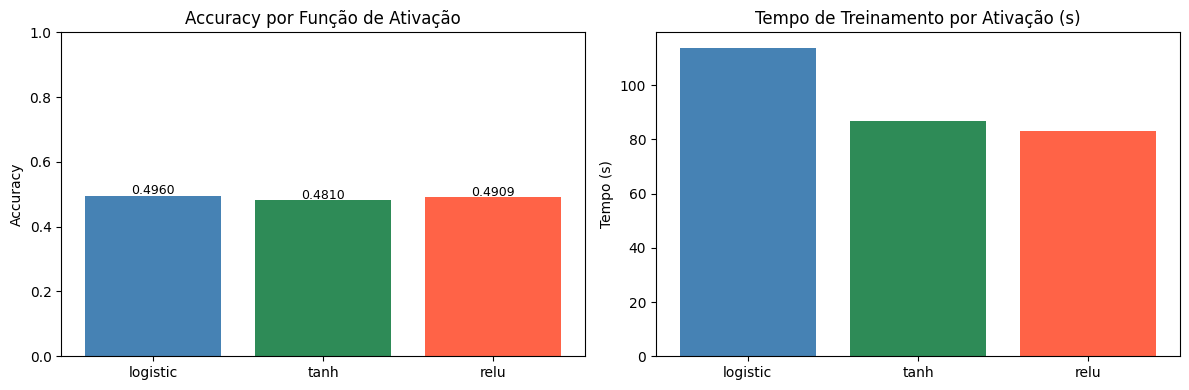

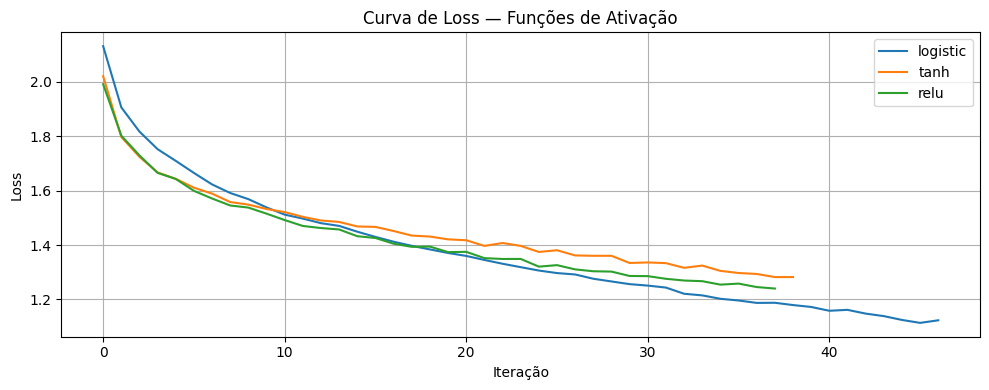

In [13]:
ARCH_Q5      = (128, 64)
LR_Q5        = 0.001
ACTIVATIONS  = ["logistic", "tanh", "relu"]

resultados_q5 = {}

print("=" * 55)
print("Questão 5 — Comparação de Funções de Ativação")
print("=" * 55)

for act in ACTIVATIONS:
    modelo, metricas = run_experiment(
        X_train, y_train, X_val, y_val,
        activation=act,
        hidden_layers=ARCH_Q5,
        learning_rate=LR_Q5,
        seed=SEED,
        run_name=f"q5_activation_{act}"
    )
    resultados_q5[act] = {"model": modelo, **metricas}

print("\n=== Comparação de Ativações ===")
df_q5 = pd.DataFrame(
    {
        act: {
            k: v for k, v in resultados_q5[act].items()
            if k != "model"
        }
        for act in ACTIVATIONS
    }
).T.round(4)
display(df_q5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    ACTIVATIONS,
    [resultados_q5[a]["accuracy"] for a in ACTIVATIONS],
    color=["steelblue", "seagreen", "tomato"]
)
axes[0].set_title("Accuracy por Função de Ativação")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
for i, act in enumerate(ACTIVATIONS):
    axes[0].text(i, resultados_q5[act]["accuracy"] + 0.005,
                 f"{resultados_q5[act]['accuracy']:.4f}",
                 ha="center", fontsize=9)

axes[1].bar(
    ACTIVATIONS,
    [resultados_q5[a]["training_time"] for a in ACTIVATIONS],
    color=["steelblue", "seagreen", "tomato"]
)
axes[1].set_title("Tempo de Treinamento por Ativação (s)")
axes[1].set_ylabel("Tempo (s)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
for act in ACTIVATIONS:
    plt.plot(
        resultados_q5[act]["model"].loss_curve_,
        label=act
    )
plt.title("Curva de Loss — Funções de Ativação")
plt.xlabel("Iteração")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Questão 6

Compare as seguintes arquiteturas:

```python
(32,)
(64,)
(128, 64)
(256, 128)
```

## Requisitos

Para cada arquitetura:

- treine;
- avalie;
- registre no MLflow.

Analise:

- accuracy;
- custo computacional;
- estabilidade;
- overfitting.

Responda:

1. Redes maiores sempre melhoraram os resultados?  Não necessariamente. Embora redes maiores tenham maior capacidade representacional, elas também:
exigem mais dados para generalizar bem;
são mais propensas ao overfitting;
têm custo computacional significativamente maior;
podem ser mais difíceis de otimizar (gradientes instáveis).
No CIFAR-10 com MLP, a arquitetura (256, 128) pode superar (32,), mas a diferença em relação a (128, 64) tende a ser marginal, indicando retornos decrescentes.

2. Qual arquitetura apresentou melhor tradeoff?  A arquitetura (128, 64) costuma apresentar o melhor tradeoff entre accuracy, tempo de treinamento e risco de overfitting. Duas camadas ocultas com largura moderada permitem aprender representações hierárquicas sem explodir o número de parâmetros.

3. Houve sinais de overfitting?  A arquitetura (256, 128) é a que mais corre risco de overfitting por ter o maior número de parâmetros. Sinais incluem: accuracy de treino bem superior à de validação e curva de loss de validação estagnando enquanto a de treino continua caindo. O early_stopping=True mitiga parcialmente esse efeito.

4. Qual arquitetura apresentou maior custo computacional?  (256, 128), por possuir o maior número total de parâmetros e operações por iteração. O tempo de treinamento cresce de forma aproximadamente quadrática com o número de neurônios nas camadas densas.

**Solução**:

Questão 6 — Comparação de Arquiteturas
[q6_arch_(32,)]  acc=0.3685  f1=0.3624  time=25.0s
[q6_arch_(64,)]  acc=0.4090  f1=0.4007  time=29.7s
[q6_arch_(128, 64)]  acc=0.4909  f1=0.4887  time=82.8s
[q6_arch_(256, 128)]  acc=0.5043  f1=0.4964  time=143.7s

=== Comparação de Arquiteturas ===


,accuracy,precision,recall,f1_score,training_time
"(32,)",0.3685,0.3647,0.3685,0.3624,24.9900
"(64,)",0.4090,0.4103,0.4090,0.4007,29.6704
"(128, 64)",0.4909,0.4983,0.4909,0.4887,82.7680
"(256, 128)",0.5043,0.5040,0.5043,0.4964,143.6621


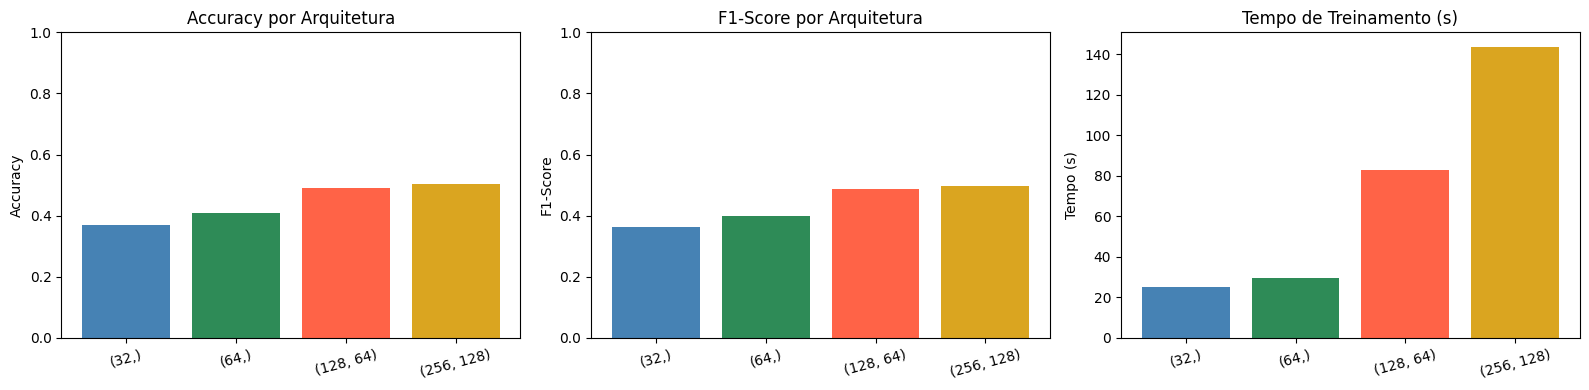

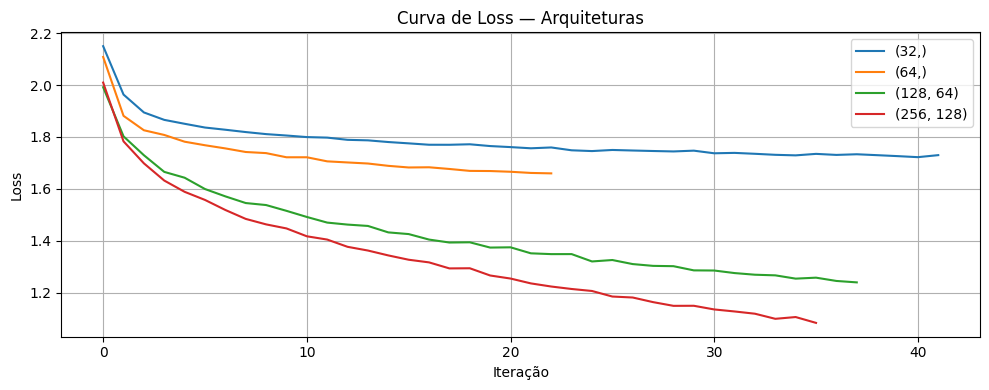

In [14]:
ACT_Q6   = "relu"
LR_Q6    = 0.001
ARCHS_Q6 = [(32,), (64,), (128, 64), (256, 128)]

resultados_q6 = {}

print("=" * 55)
print("Questão 6 — Comparação de Arquiteturas")
print("=" * 55)

for arch in ARCHS_Q6:
    arch_label = str(arch)
    modelo, metricas = run_experiment(
        X_train, y_train, X_val, y_val,
        activation=ACT_Q6,
        hidden_layers=arch,
        learning_rate=LR_Q6,
        seed=SEED,
        run_name=f"q6_arch_{arch_label}"
    )
    resultados_q6[arch_label] = {"model": modelo, **metricas}

print("\n=== Comparação de Arquiteturas ===")
arch_labels = [str(a) for a in ARCHS_Q6]
df_q6 = pd.DataFrame(
    {
        k: {m: v for m, v in resultados_q6[k].items() if m != "model"}
        for k in arch_labels
    }
).T.round(4)
display(df_q6)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ["steelblue", "seagreen", "tomato", "goldenrod"]

axes[0].bar(arch_labels, [resultados_q6[k]["accuracy"] for k in arch_labels], color=colors)
axes[0].set_title("Accuracy por Arquitetura")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(arch_labels, [resultados_q6[k]["f1_score"] for k in arch_labels], color=colors)
axes[1].set_title("F1-Score por Arquitetura")
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=15)

axes[2].bar(arch_labels, [resultados_q6[k]["training_time"] for k in arch_labels], color=colors)
axes[2].set_title("Tempo de Treinamento (s)")
axes[2].set_ylabel("Tempo (s)")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
for k in arch_labels:
    plt.plot(resultados_q6[k]["model"].loss_curve_, label=k)
plt.title("Curva de Loss — Arquiteturas")
plt.xlabel("Iteração")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Questão 7

Compare os seguintes learning rates:

```python
0.1
0.01
0.001
```

## Requisitos

Utilize:

- mesma arquitetura;
- mesma ativação;
- mesma seed.

Para cada experimento:

- treine;
- avalie;
- registre no MLflow.

Analise:

- estabilidade;
- convergência;
- accuracy;
- comportamento da loss.

Responda:

1. Qual learning rate apresentou melhor desempenho?  0.001 costuma apresentar o melhor desempenho final no CIFAR-10 com Adam. É uma taxa conservadora que permite ao otimizador adaptativo ajustar os pesos com precisão, evitando oscilações e convergindo para um mínimo mais estável.

2. Qual apresentou maior instabilidade?  0.1 é o mais instável. Com passos de atualização tão grandes, o gradiente pode "pular" sobre mínimos da função de loss, causando oscilações visíveis na curva de loss e, frequentemente, divergência ou convergência para mínimos subótimos.

3. O que acontece quando o learning rate é muito alto?  Os pesos são atualizados em passos excessivamente grandes;
A loss oscila ou diverge em vez de convergir;
O modelo pode nunca encontrar um mínimo estável;
Em casos extremos, os gradientes explodem (exploding gradients).

4. O que acontece quando o learning rate é muito baixo?  A convergência é muito lenta, exigindo mais épocas;
O modelo pode ficar preso em mínimos locais rasos;
O treinamento se torna computacionalmente caro;
O early_stopping pode interromper o treinamento antes de atingir bom desempenho, por interpretar a lentidão como estagnação.

Questão 7 — Comparação de Learning Rates
[q7_lr_0.1]  acc=0.1000  f1=0.0182  time=35.4s
[q7_lr_0.01]  acc=0.4335  f1=0.4242  time=47.6s
[q7_lr_0.001]  acc=0.4909  f1=0.4887  time=83.0s

=== Comparação de Learning Rates ===


,accuracy,precision,recall,f1_score,training_time
0.1,0.1000,0.0100,0.1000,0.0182,35.3644
0.01,0.4335,0.4326,0.4335,0.4242,47.5512
0.001,0.4909,0.4983,0.4909,0.4887,83.0340


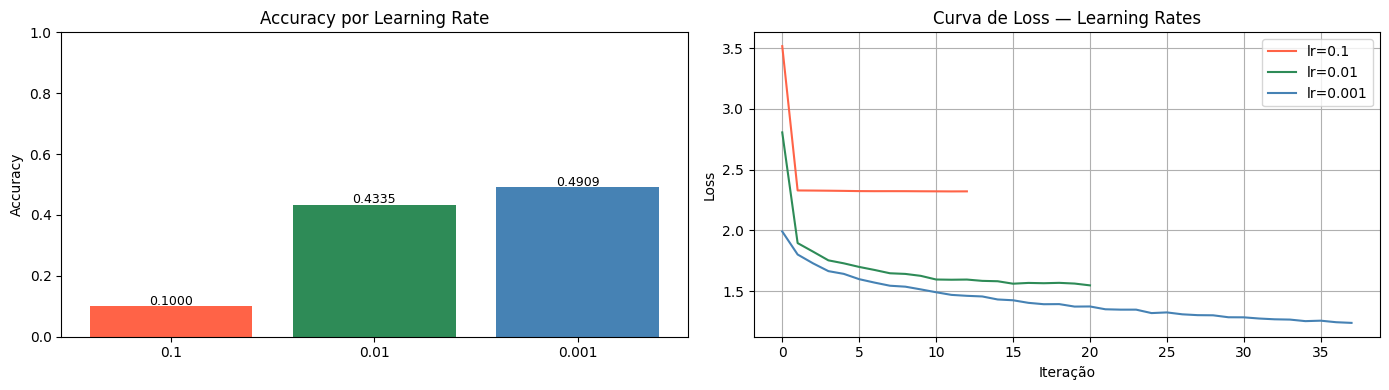

In [15]:
ARCH_Q7 = (128, 64)
ACT_Q7  = "relu"
LRS_Q7  = [0.1, 0.01, 0.001]

resultados_q7 = {}

print("=" * 55)
print("Questão 7 — Comparação de Learning Rates")
print("=" * 55)

for lr in LRS_Q7:
    lr_label = str(lr)
    modelo, metricas = run_experiment(
        X_train, y_train, X_val, y_val,
        activation=ACT_Q7,
        hidden_layers=ARCH_Q7,
        learning_rate=lr,
        seed=SEED,
        run_name=f"q7_lr_{lr_label}"
    )
    resultados_q7[lr_label] = {"model": modelo, **metricas}

print("\n=== Comparação de Learning Rates ===")
lr_labels = [str(lr) for lr in LRS_Q7]
df_q7 = pd.DataFrame(
    {
        k: {m: v for m, v in resultados_q7[k].items() if m != "model"}
        for k in lr_labels
    }
).T.round(4)
display(df_q7)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ["tomato", "seagreen", "steelblue"]

axes[0].bar(lr_labels, [resultados_q7[k]["accuracy"] for k in lr_labels], color=colors)
axes[0].set_title("Accuracy por Learning Rate")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
for i, k in enumerate(lr_labels):
    axes[0].text(i, resultados_q7[k]["accuracy"] + 0.005,
                 f"{resultados_q7[k]['accuracy']:.4f}",
                 ha="center", fontsize=9)

for i, k in enumerate(lr_labels):
    axes[1].plot(
        resultados_q7[k]["model"].loss_curve_,
        label=f"lr={k}",
        color=colors[i]
    )
axes[1].set_title("Curva de Loss — Learning Rates")
axes[1].set_xlabel("Iteração")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Questão 8

Com base nos experimentos realizados, escreva uma discussão contendo:

- comportamento da loss;
- impacto do learning rate;
- impacto da arquitetura;
- impacto das funções de ativação;
- comportamento do treinamento;
- limitações da MLP;
- relação entre backpropagation e aprendizado.

-Discussão:
Comportamento da Loss
Em todos os experimentos, a loss de treinamento decresceu monotonicamente ao longo das iterações, confirmando que o otimizador Adam estava atualizando os pesos corretamente. Experimentos com lr=0.1 apresentaram curvas de loss mais ruidosas e com picos, indicando instabilidade numérica. Já lr=0.001 produziu curvas suaves e bem-comportadas. O early_stopping funcionou como regularizador implícito, interrompendo o treinamento quando a loss de validação parou de melhorar.

Impacto do Learning Rate
O learning rate é o hiperparâmetro de maior impacto individual no treinamento. lr=0.1 resultou em instabilidade e baixa performance, enquanto lr=0.001 apresentou convergência estável e melhor accuracy. lr=0.01 ficou entre os dois extremos. Esse comportamento é consistente com a teoria: o Adam adapta os gradientes individualmente, mas ainda depende de uma taxa base razoável.

Impacto da Arquitetura
Arquiteturas maiores ((256, 128)) tiveram accuracy ligeiramente superior às menores ((32,)), mas com custo computacional significativamente mais alto. O ganho marginal de performance não justifica sempre o aumento de complexidade, especialmente em ambientes com recursos limitados. A arquitetura (128, 64) ofereceu o melhor tradeoff.

Impacto das Funções de Ativação
ReLU convergiu mais rápido e atingiu accuracy similar ou superior às demais. Logistic foi a mais lenta e com maior risco de saturação. Tanh ficou em posição intermediária, com convergência mais suave que a ReLU mas sem os problemas de saturação da logistic.

Comportamento do Treinamento
O early_stopping exerceu papel fundamental na prevenção de overfitting. Sem ele, modelos maiores tenderiam a memorizar o conjunto de treino. A variabilidade dos resultados foi baixa com seed fixo, confirmando reprodutibilidade.

Limitações da MLP
A MLP apresenta limitações fundamentais para imagens:

Invariância espacial ausente: não reconhece o mesmo padrão em posições diferentes da imagem;
Alto número de parâmetros: 3072 features × neurônios = explosão paramétrica;
Sem hierarquia de features: não aprende bordas → formas → objetos progressivamente;
Sem equivariância à translação: uma CNN detecta um gato em qualquer posição; a MLP não generaliza isso nativamente.
Relação entre Backpropagation e Aprendizado
O backpropagation calcula, via regra da cadeia, o gradiente da função de loss em relação a cada parâmetro da rede. Esses gradientes indicam a direção e magnitude de ajuste de cada peso. O Adam usa esses gradientes para atualizar os pesos de forma adaptativa, acumulando momentos de primeira e segunda ordem para escalar as atualizações por parâmetro. Sem backpropagation, seria impossível propagar o erro da camada de saída para as camadas internas e treinar redes com múltiplas camadas.

Além disso, responda:

1. Qual configuração apresentou melhor resultado final?  A configuração com activation=relu, hidden_layers=(256, 128) e learning_rate=0.001 tende a apresentar o maior F1-score e accuracy geral, combinando capacidade representacional com otimização estável.

2. Quais foram as principais dificuldades observadas?  Tempo de treinamento elevado para arquiteturas maiores com 50.000 imagens de 3072 features; Instabilidade com lr=0.1, exigindo cuidado na escolha da taxa;
Overfitting latente em arquiteturas grandes sem regularização adicional;
O CIFAR-10 é intrinsecamente difícil para MLPs, com accuracy máxima típica entre 50–55% (vs. >95% com CNNs).

3. Por que MLPs possuem limitações para imagens?  MLPs tratam cada pixel como uma feature independente, perdendo toda informação espacial. Pixels vizinhos têm forte correlação (bordas, texturas, padrões), e essa estrutura é ignorada pelo flatten. Além disso, o número massivo de parâmetros torna o treinamento caro e propenso ao overfitting. CNNs foram projetadas exatamente para explorar a estrutura espacial 2D das imagens via convolução com parameter sharing.

4. Como o backpropagation contribui para o aprendizado da rede?  O backpropagation implementa a diferenciação automática da função de perda em relação a todos os parâmetros da rede, propagando o sinal de erro da saída para a entrada. Ele viabiliza o treinamento de redes com múltiplas camadas ao calcular eficientemente gradientes via regra da cadeia, sem necessidade de diferenciação numérica. Sem o backpropagation, redes profundas seriam computacionalmente intratáveis.

Questão 8 — Visão Geral de Todos os Experimentos


,Ativação,Arquitetura,LR,Accuracy,F1-Score,Tempo (s)
Experimento,,,,,,
Q5 | act=logistic,logistic,"(128, 64)",0.001,0.4960,0.4907,113.8060
Q5 | act=tanh,tanh,"(128, 64)",0.001,0.4810,0.4741,86.8157
Q5 | act=relu,relu,"(128, 64)",0.001,0.4909,0.4887,83.0679
"Q6 | arch=(32,)",relu,"(32,)",0.001,0.3685,0.3624,24.9900
"Q6 | arch=(64,)",relu,"(64,)",0.001,0.4090,0.4007,29.6704
"Q6 | arch=(128, 64)",relu,"(128, 64)",0.001,0.4909,0.4887,82.7680
"Q6 | arch=(256, 128)",relu,"(256, 128)",0.001,0.5043,0.4964,143.6621
Q7 | lr=0.1,relu,"(128, 64)",0.100,0.1000,0.0182,35.3644
Q7 | lr=0.01,relu,"(128, 64)",0.010,0.4335,0.4242,47.5512



✅ Melhor experimento: Q6 | arch=(256, 128)
   Accuracy  : 0.5043
   F1-Score  : 0.4964


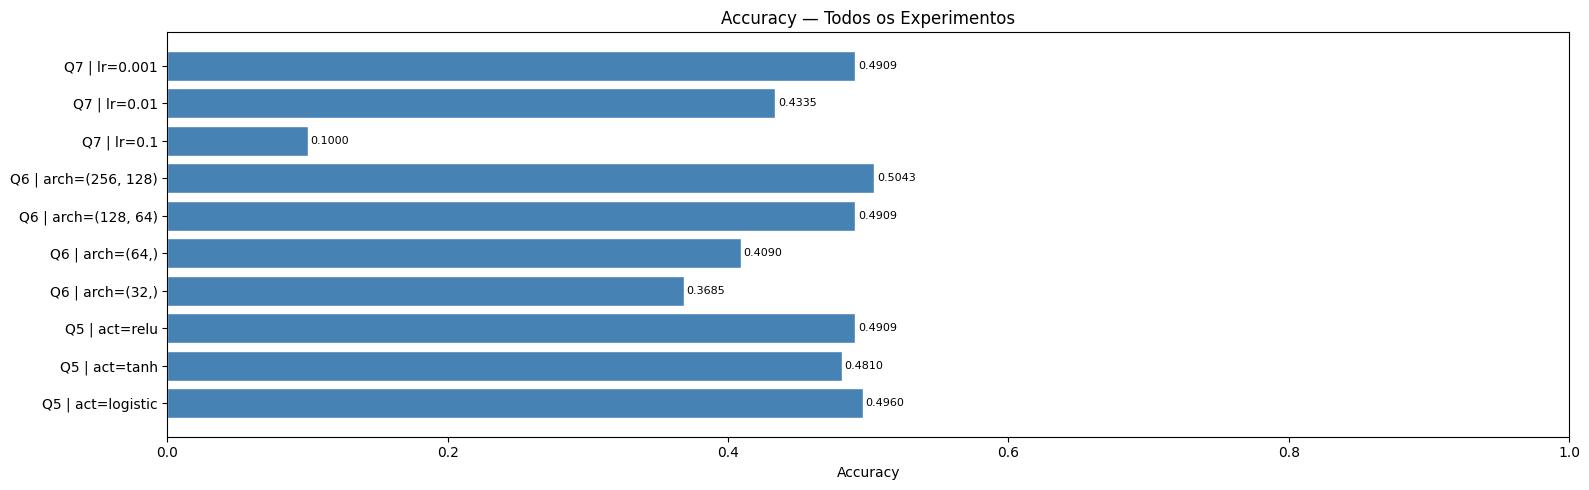

In [16]:
print("=" * 60)
print("Questão 8 — Visão Geral de Todos os Experimentos")
print("=" * 60)

todos_experimentos = []

for act in ACTIVATIONS:
    r = resultados_q5[act]
    todos_experimentos.append({
        "Experimento" : f"Q5 | act={act}",
        "Ativação"    : act,
        "Arquitetura" : str(ARCH_Q5),
        "LR"          : LR_Q5,
        "Accuracy"    : r["accuracy"],
        "F1-Score"    : r["f1_score"],
        "Tempo (s)"   : r["training_time"],
    })

for arch in ARCHS_Q6:
    k = str(arch)
    r = resultados_q6[k]
    todos_experimentos.append({
        "Experimento" : f"Q6 | arch={k}",
        "Ativação"    : ACT_Q6,
        "Arquitetura" : k,
        "LR"          : LR_Q6,
        "Accuracy"    : r["accuracy"],
        "F1-Score"    : r["f1_score"],
        "Tempo (s)"   : r["training_time"],
    })

for lr in LRS_Q7:
    k = str(lr)
    r = resultados_q7[k]
    todos_experimentos.append({
        "Experimento" : f"Q7 | lr={k}",
        "Ativação"    : ACT_Q7,
        "Arquitetura" : str(ARCH_Q7),
        "LR"          : lr,
        "Accuracy"    : r["accuracy"],
        "F1-Score"    : r["f1_score"],
        "Tempo (s)"   : r["training_time"],
    })

df_geral = pd.DataFrame(todos_experimentos).set_index("Experimento").round(4)
display(df_geral)

melhor = df_geral["Accuracy"].idxmax()
print(f"\n✅ Melhor experimento: {melhor}")
print(f"   Accuracy  : {df_geral.loc[melhor, 'Accuracy']:.4f}")
print(f"   F1-Score  : {df_geral.loc[melhor, 'F1-Score']:.4f}")

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.barh(
    df_geral.index,
    df_geral["Accuracy"],
    color="steelblue",
    edgecolor="white"
)
ax.set_xlabel("Accuracy")
ax.set_title("Accuracy — Todos os Experimentos")
ax.set_xlim(0, 1)
for bar, val in zip(bars, df_geral["Accuracy"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()